In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
import os

WORK_DIR = "/content/drive/MyDrive/pw_analysis"
DATA_DIR = f"{WORK_DIR}/data_clean/data_processed"
OUT_DIR  = f"{WORK_DIR}/outputs"

# Create directories if they don't exist
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)


In [20]:
# ── STEP 1: Load township-level data and aggregate to county ──────
raw = pd.read_csv(f"{DATA_DIR}/nm_cross_validation.csv")
print(f"Raw township-level file: {len(raw)} rows across "
      f"{raw['county_key'].nunique()} counties\n")

cv = (raw.groupby("county_key", as_index=False)
          .agg(total_pw_vol   = ("qty_5yr_real",  "sum"),
               swd_count      = ("swd_well_count","first"),
               oil_well_count = ("oil_well_count","first"),
               township_count = ("geo_id",        "count"),
               median_tds     = ("tds_real",      "median"),
               max_tds        = ("tds_real",      "max"))
          .sort_values("total_pw_vol", ascending=False)
          .reset_index(drop=True))

Raw township-level file: 254 rows across 5 counties



In [21]:
print("═══ COUNTY-LEVEL AGGREGATED DATA ═══")
print(cv.to_string(index=False))

═══ COUNTY-LEVEL AGGREGATED DATA ═══
county_key  total_pw_vol  swd_count  oil_well_count  township_count  median_tds   max_tds
      eddy  1363808569.0        636           29352              79  130234.000 312846.34
       lea  1018620223.0        870           38315             134  100309.775 266151.01
  san juan    49534489.0        115            3501              34   19070.560  79667.00
rio arriba     8066042.0         26            1542               6   16243.800  22422.59
  mckinley       30253.0          9            1091               1   10594.500  10594.50


In [22]:
# Save for future runs
cv.to_csv(f"{DATA_DIR}/nm_cross_validation_county.csv", index=False)
print(f"\n✓ Saved: nm_cross_validation_county.csv")


✓ Saved: nm_cross_validation_county.csv


In [23]:
# ── STEP 2: Exact permutation Spearman (correct for n=5) ──────────
# scipy default uses t-approx which is unreliable at n<10
# PermutationMethod builds the exact null distribution instead

# Define a statistic function for permutation_test that returns Spearman's r
def spearman_r_statistic(x, y):
    return stats.spearmanr(x, y).correlation

# Calculate Spearman's r and p-value for PW vs oil wells using permutation_test
# The r value itself comes from a direct spearmanr call
r_oil_val = spearman_r_statistic(cv["total_pw_vol"], cv["oil_well_count"])
res_oil = stats.permutation_test(
    (cv["total_pw_vol"], cv["oil_well_count"]),
    spearman_r_statistic,
    permutation_type='pairings', # 'pairings' is suitable for correlation between two paired samples
    n_resamples=10000,
    random_state=42,
    alternative='two-sided'
)
p_oil = res_oil.pvalue

# Calculate Spearman's r and p-value for PW vs SWD wells using permutation_test
r_swd_val = spearman_r_statistic(cv["total_pw_vol"], cv["swd_count"])
res_swd = stats.permutation_test(
    (cv["total_pw_vol"], cv["swd_count"]),
    spearman_r_statistic,
    permutation_type='pairings',
    n_resamples=10000,
    random_state=42,
    alternative='two-sided'
)
p_swd = res_swd.pvalue

# Pearson correlation as before
r_pear, p_pear = stats.pearsonr(cv["total_pw_vol"], cv["oil_well_count"])

print(f"\n═══ CORRELATION RESULTS (n = {len(cv)}) ═══")
print(f"Spearman (PW vs oil wells):  r = {r_oil_val:.3f}, "
      f"exact perm p = {p_oil:.4f} (two-sided)")
print(f"Spearman (PW vs SWD wells):  r = {r_swd_val:.3f}, "
      f"exact perm p = {p_swd:.4f} (two-sided)")
print(f"Pearson  (PW vs oil wells):  r = {r_pear:.3f}, "
      f"p = {p_pear:.4f}")


═══ CORRELATION RESULTS (n = 5) ═══
Spearman (PW vs oil wells):  r = 0.900, exact perm p = 0.0828 (two-sided)
Spearman (PW vs SWD wells):  r = 0.900, exact perm p = 0.0828 (two-sided)
Pearson  (PW vs oil wells):  r = 0.933, p = 0.0206


In [24]:
# Compare to the invalid scipy default (for the record — do NOT report this)
r_default, p_default = stats.spearmanr(cv["total_pw_vol"], cv["oil_well_count"])
print(f"\n[For reference: scipy default (t-approx, invalid at n=5): "
      f"p = {p_default:.4f}]")
print(f"[Reporting the t-approx value would overstate significance.]")



[For reference: scipy default (t-approx, invalid at n=5): p = 0.0374]
[Reporting the t-approx value would overstate significance.]


In [25]:
# ── STEP 3: Leave-one-out sensitivity ─────────────────────────────
print(f"\n═══ LEAVE-ONE-OUT SENSITIVITY ═══")
print(f"{'Excluded county':<15} {'n':>3} {'Spearman r':>12} {'exact p':>10}")
print("─" * 45)


═══ LEAVE-ONE-OUT SENSITIVITY ═══
Excluded county   n   Spearman r    exact p
─────────────────────────────────────────────


In [26]:
loo_results = []
for _, row in cv.iterrows():
    subset = cv[cv["county_key"] != row["county_key"]]

    # Calculate r_loo using spearmanr without method argument
    r_loo = stats.spearmanr(subset["total_pw_vol"], subset["oil_well_count"]).correlation

    # Calculate p_loo using permutation_test
    res_loo = stats.permutation_test(
        (subset["total_pw_vol"], subset["oil_well_count"]),
        spearman_r_statistic, # Use the statistic function defined earlier
        permutation_type='pairings',
        n_resamples=10000,
        random_state=42,
        alternative='two-sided'
    )
    p_loo = res_loo.pvalue

    loo_results.append({
        "excluded_county": row["county_key"],
        "n": len(subset),
        "spearman_r": round(r_loo, 3),
        "exact_p":    round(p_loo, 4),
    })
    print(f"{row['county_key']:<15} {len(subset):>3} "
          f"{r_loo:>12.3f} {p_loo:>10.4f}")

eddy              4        1.000     0.0833
lea               4        1.000     0.0833
san juan          4        0.800     0.3333
rio arriba        4        0.800     0.3333
mckinley          4        0.800     0.3333


In [27]:
loo_df = pd.DataFrame(loo_results)
loo_df.to_csv(f"{OUT_DIR}/leave_one_out_sensitivity.csv", index=False)
print(f"\n✓ Saved: leave_one_out_sensitivity.csv")


✓ Saved: leave_one_out_sensitivity.csv


In [ ]:
#!!! didn't produce outputs!!! ── STEP 4: Corrected figure ──────────────────────────────────────
def county_style(county):─. . 
    """Diamond marker + orange for gas basin, circle + blue for oil basin"""
    if county in ("san juan", "rio arriba"):
        return {"c":"#c2410c", "marker":"D", "group":"Gas basin"}
    else:
        return {"c":"#1e40af", "marker":"o", "group":"Permian oil basin"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    "Convergent consistency check: PW volume vs independent regulatory "
    "well counts, county level (n = 5)",
    fontsize=11.5, fontweight="bold", y=0.995
)

In [29]:
panels = [
    ("PW volume vs oil well density",
        cv["oil_well_count"], "Oil Well Count (per county)", r_oil_val, p_oil),
    ("PW volume vs disposal infrastructure",
        cv["swd_count"], "SWD Well Count (per county)",    r_swd_val, p_swd),
]

seen_groups = set()
for i, (title, y, y_label, r_val, p_val) in enumerate(panels):
    ax = axes[i]

In [30]:
# Plot each county with type-based styling; single legend entry per group
for _, row in cv.iterrows():
    style = county_style(row["county_key"])
    label = (style["group"]
             if (i == 0 and style["group"] not in seen_groups) else None)
    if label:
        seen_groups.add(label)
    y_val = y.loc[cv.index[cv["county_key"] == row["county_key"]][0]]
    ax.scatter(row["total_pw_vol"], y_val,
               c=style["c"], marker=style["marker"],
               s=110, alpha=0.9, edgecolor="white", linewidth=1.8,
               label=label, zorder=3)
    # Non-overlapping county labels
    ax.annotate(row["county_key"].title(),
                (row["total_pw_vol"], y_val),
                xytext=(9, 5), textcoords="offset points",
                fontsize=9, color="#374151", zorder=4)

# Log-scale both axes (reviewer fix: prevents low-vol counties piling at margin)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Produced Water Volume, 5-year total (barrels)  [log]",
              fontsize=9.5)
ax.set_ylabel(f"{y_label}  [log]", fontsize=9.5)
ax.set_title(title, fontsize=10.5)

# NO dashed regression line — parametric fit alongside rank statistic
# is inappropriate and dragged by 2 leverage points

# Annotation: exact permutation p, honest about significance
threshold_note = ("Does NOT clear 0.05 threshold" if p_val > 0.05
                  else "Clears 0.05 threshold")
ax.text(0.04, 0.96,
        f"Spearman r = {r_val:.3f}\n"
        f"Exact permutation p = {p_val:.3f}\n"
        f"{threshold_note}",
        transform=ax.transAxes, fontsize=8.5, color="#065A82",
        verticalalignment="top", family="monospace",
        bbox=dict(facecolor="white", edgecolor="#CBD5E1",
                 boxstyle="round,pad=0.4", alpha=0.95))

ax.grid(alpha=0.3, which="both", linestyle=":", linewidth=0.5)
ax.set_axisbelow(True)

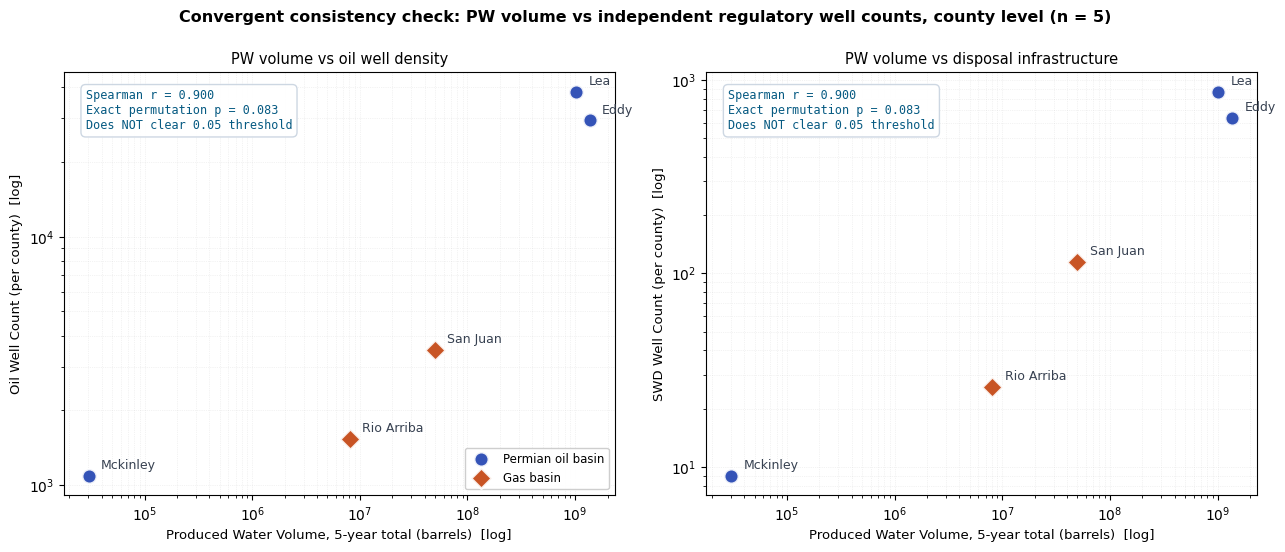


✓ Saved: convergent_consistency_check.png

═══ SUMMARY FOR THESIS ═══
  n_counties                   5
  spearman_r_oil               0.9
  exact_perm_p_oil             0.0828
  spearman_r_swd               0.9
  exact_perm_p_swd             0.0828
  pearson_r_oil                0.9329
  pearson_p_oil                0.0206
  scipy_default_p_invalid      0.0374
  clears_05_threshold          False

✓ Saved: convergent_consistency_stats.csv

Done. Update Section 6.2 figure with convergent_consistency_check.png


In [31]:
# ── STEP 4: Corrected figure ──────────────────────────────────────
def county_style(county):
    """Diamond marker + orange for gas basin, circle + blue for oil basin"""
    if county in ("san juan", "rio arriba"):
        return {"c":"#c2410c", "marker":"D", "group":"Gas basin"}
    else:
        return {"c":"#1e40af", "marker":"o", "group":"Permian oil basin"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    "Convergent consistency check: PW volume vs independent regulatory "
    "well counts, county level (n = 5)",
    fontsize=11.5, fontweight="bold", y=0.995
)

panels = [
    ("PW volume vs oil well density",
        cv["oil_well_count"], "Oil Well Count (per county)", r_oil_val, p_oil),
    ("PW volume vs disposal infrastructure",
        cv["swd_count"], "SWD Well Count (per county)",    r_swd_val, p_swd),
]

seen_groups = set()
for i, (title, y, y_label, r_val, p_val) in enumerate(panels):
    ax = axes[i]

    # Plot each county with type-based styling; single legend entry per group
    for _, row in cv.iterrows():
        style = county_style(row["county_key"])
        label = (style["group"]
                 if (i == 0 and style["group"] not in seen_groups) else None)
        if label:
            seen_groups.add(label)
        y_val = y.loc[cv.index[cv["county_key"] == row["county_key"]][0]]
        ax.scatter(row["total_pw_vol"], y_val,
                   c=style["c"], marker=style["marker"],
                   s=110, alpha=0.9, edgecolor="white", linewidth=1.8,
                   label=label, zorder=3)
        # Non-overlapping county labels
        ax.annotate(row["county_key"].title(),
                    (row["total_pw_vol"], y_val),
                    xytext=(9, 5), textcoords="offset points",
                    fontsize=9, color="#374151", zorder=4)

    # Log-scale both axes (reviewer fix: prevents low-vol counties piling at margin)
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Produced Water Volume, 5-year total (barrels)  [log]",
                  fontsize=9.5)
    ax.set_ylabel(f"{y_label}  [log]", fontsize=9.5)
    ax.set_title(title, fontsize=10.5)

    # NO dashed regression line — parametric fit alongside rank statistic
    # is inappropriate and dragged by 2 leverage points

    # Annotation: exact permutation p, honest about significance
    #threshold_note = ("Does NOT clear 0.05 threshold" if p_val > 0.05
                      #else "Clears 0.05 threshold")
    ax.text(0.04, 0.96,
            f"Spearman r = {r_val:.3f}\n"
            f"Exact permutation p = {p_val:.3f}\n"
            f"{threshold_note}",
            transform=ax.transAxes, fontsize=8.5, color="#065A82",
            verticalalignment="top", family="monospace",
            bbox=dict(facecolor="white", edgecolor="#CBD5E1",
                     boxstyle="round,pad=0.4", alpha=0.95))

    ax.grid(alpha=0.3, which="both", linestyle=":", linewidth=0.5)
    ax.set_axisbelow(True)

# Legend only on left panel
axes[0].legend(fontsize=8.5, loc="lower right", framealpha=0.95)

# Honest caption under both panels
fig.text(0.5, -0.04, "",
         ha="center", fontsize=8.5, color="#64748b", style="italic")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/convergent_consistency_check.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n✓ Saved: convergent_consistency_check.png")

# ── STEP 5: Save summary stats for the thesis ────────────────────
summary = {
    "n_counties":              len(cv),
    "spearman_r_oil":          round(r_oil_val,  4),
    "exact_perm_p_oil":        round(p_oil,  4),
    "spearman_r_swd":          round(r_swd_val,  4),
    "exact_perm_p_swd":        round(p_swd,  4),
    "pearson_r_oil":           round(r_pear, 4),
    "pearson_p_oil":           round(p_pear, 4),
    "scipy_default_p_invalid": round(p_default, 4),
    "clears_05_threshold":     bool(p_oil < 0.05),
}
pd.DataFrame([summary]).to_csv(
    f"{OUT_DIR}/convergent_consistency_stats.csv", index=False)

print(f"\n═══ SUMMARY FOR THESIS ═══")
for k, v in summary.items():
    print(f"  {k:<28} {v}")
print(f"\n✓ Saved: convergent_consistency_stats.csv")
print("\nDone. Update Section 6.2 figure with convergent_consistency_check.png")

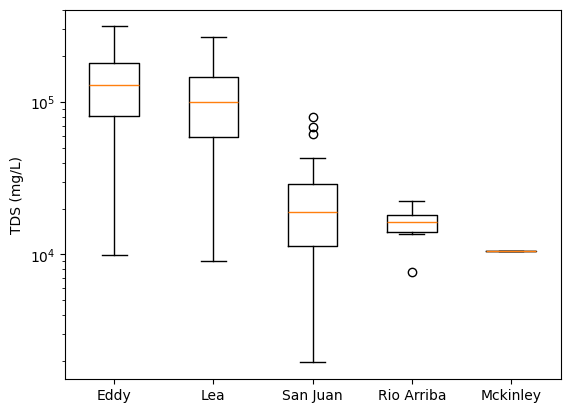

In [32]:
counties = ['eddy','lea','san juan','rio arriba','mckinley']
data = [raw[raw.county_key==c].tds_real.dropna() for c in counties]
plt.boxplot(data, tick_labels=[c.title() for c in counties])
plt.ylabel('TDS (mg/L)'); plt.yscale('log')

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CANONICAL k=4 CLUSTERING
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, silhouette_samples)

WORK_DIR = "/content/drive/MyDrive/pw_analysis"
DATA_DIR = f"{WORK_DIR}/data_clean/data_processed"

# ── Load and re-cluster with k=4 for reproducibility ──────────────
pw = pd.read_csv(f"{DATA_DIR}/nm_cross_validation.csv")
features = ["log_qty_5yr", "log_tds", "ts_trend_norm", "ts_volatility_norm"]

valid = pw.dropna(subset=features).copy()

# Handle infinite values (e.g., from log(0) resulting in -inf) before scaling
# MinMaxScaler cannot handle infinite values.
print(f"Original `valid` shape before handling infinities: {valid.shape}")
valid.replace([np.inf, -np.inf], np.nan, inplace=True)
valid.dropna(subset=features, inplace=True)
print(f"New `valid` shape after handling infinities: {valid.shape}")
X = MinMaxScaler().fit_transform(valid[features])

# Re-fit deterministically
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
valid["cluster"] = km.labels_

# Save canonical CSV — overwrites the 3-populated version
pw_final = pw.merge(valid[["geo_id","cluster"]].rename(columns={"cluster":"cluster_k4"}),
                     on="geo_id", how="left")
pw_final["cluster"] = pw_final["cluster_k4"].fillna(pw_final["cluster"])
pw_final = pw_final.drop(columns=["cluster_k4"])
pw_final.to_csv(f"{DATA_DIR}/nm_pw_clusters.csv", index=False)
print(f"✓ Overwrote nm_pw_clusters.csv with k=4 clustering")

# ── Composition ──────────────────────────────────────────────────
print("\n═══ CLUSTER COMPOSITION (k=4) ═══")
composition = (valid.groupby("cluster")
               .agg(n=("geo_id","count"),
                    median_vol=("qty_5yr_real","median"),
                    mean_vol=("qty_5yr_real","mean"),
                    median_tds=("tds_real","median"),
                    mean_tds=("tds_real","mean"),
                    median_trend=("ts_trend_norm","median"),
                    median_volatility=("ts_volatility_norm","median"),
                    counties=("county", lambda x: sorted(set(x))))
               .round(1))
print(composition.to_string())

# ── Full metrics on this canonical clustering ────────────────────
labels = valid["cluster"].values
sil = silhouette_score(X, labels)
db  = davies_bouldin_score(X, labels)
ch  = calinski_harabasz_score(X, labels)
sil_samples = silhouette_samples(X, labels)

print(f"\n═══ INTERNAL METRICS (k=4) ═══")
print(f"n samples          : {len(labels)}")
print(f"Silhouette         : {sil:.3f}")
print(f"Davies-Bouldin     : {db:.3f}")
print(f"Calinski-Harabasz  : {ch:.1f}")
print(f"Negative silhouettes: {(sil_samples < 0).sum()} of {len(sil_samples)}")

per_cluster = (pd.DataFrame({"cluster": labels, "sil": sil_samples})
               .groupby("cluster")
               .agg(n=("sil","size"),
                    mean_sil=("sil","mean"),
                    min_sil=("sil","min"),
                    max_sil=("sil","max"))
               .round(3))
print(f"\n═══ PER-CLUSTER SILHOUETTE (k=4) ═══")
print(per_cluster.to_string())

# ── County-level dominant cluster ──────
print(f"\n═══ DOMINANT CLUSTER PER COUNTY ═══")
county_dom = (valid.groupby("county")["cluster"]
              .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else -1)
              .to_dict())
for county, dom in county_dom.items():
    n_total = (valid["county"] == county).sum()
    n_dom = ((valid["county"] == county) & (valid["cluster"] == dom)).sum()
    print(f"  {county:12} → Cluster {dom}  ({n_dom}/{n_total} townships)")

Original `valid` shape before handling infinities: (253, 20)
New `valid` shape after handling infinities: (248, 20)
✓ Overwrote nm_pw_clusters.csv with k=4 clustering

═══ CLUSTER COMPOSITION (k=4) ═══
           n  median_vol    mean_vol  median_tds  mean_tds  median_trend  median_volatility                                     counties
cluster                                                                                                                                 
0         53    843692.0   2165552.6     17935.0   19315.5          -0.0                0.2  [eddy, lea, mckinley, rio arriba, san juan]
1         74    369501.5    530034.2    112224.2  123171.4          -0.0                0.3                        [eddy, lea, san juan]
2          4       142.0       801.0    121576.5  119176.4        -147.2             1798.4                        [eddy, lea, san juan]
3        117  11965221.0  19533444.2    116461.4  130115.3           0.0                0.1                      

**Cluster Profile Heatmap**

This section visualizes the mean feature values for each of the 4 clusters. It calculates Z-scores of these mean features across clusters to represent how each feature deviates from the overall mean, and uses a heatmap to display these Z-scores with the actual mean values annotated.
The clusters are reordered to match a 'thesis order' for consistency and given descriptive labels. The heatmap is saved as cluster_profile_heatmap.png.

Cluster distribution (should match thesis):
cluster
0     53
1     74
2      4
3    117
Name: count, dtype: int64


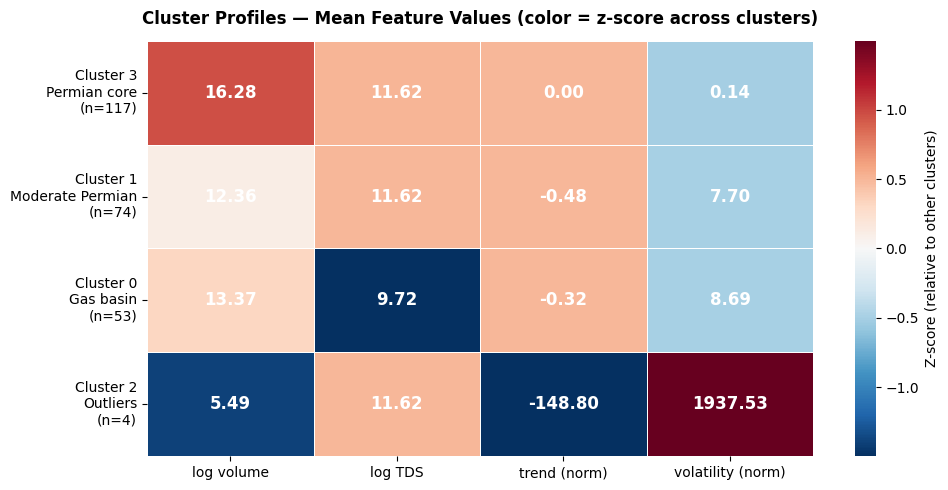


✓ Saved: cluster_profile_heatmap.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

WORK_DIR = "/content/drive/MyDrive/pw_analysis"
DATA_DIR = f"{WORK_DIR}/data_clean/data_processed"
OUT_DIR  = f"{WORK_DIR}/outputs"

# ── Load canonical clustering ─────────────────────────────────────
pw = pd.read_csv(f"{DATA_DIR}/nm_pw_clusters.csv")
features = ["log_qty_5yr", "log_tds", "ts_trend_norm", "ts_volatility_norm"]
valid = pw.dropna(subset=features + ["cluster"]).copy()
valid["cluster"] = valid["cluster"].astype(int)

# Verify we're using the canonical thesis labeling
print("Cluster distribution (should match thesis):")
print(valid["cluster"].value_counts().sort_index())
# Expected: 0→53, 1→74, 2→4, 3→117

# ── Compute mean feature values per cluster ──────────────────────
cluster_means = valid.groupby("cluster")[features].mean()

# ── Z-score across clusters for coloring ─────────────────────────
z_scores = cluster_means.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

# ── Reorder clusters by median volume for readability ────────────
# Thesis order: 3 (Permian core) → 1 (moderate Permian) → 0 (gas) → 2 (outliers)
thesis_order = [3, 1, 0, 2]
cluster_means = cluster_means.reindex(thesis_order)
z_scores = z_scores.reindex(thesis_order)

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(z_scores, annot=cluster_means.round(2), fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Z-score (relative to other clusters)"},
            annot_kws={"size": 12, "color": "white", "weight": "bold"},
            linewidths=0.5, linecolor="white")

# Thesis-consistent labels
regime_labels = ["Cluster 3\nPermian core\n(n=117)",
                 "Cluster 1\nModerate Permian\n(n=74)",
                 "Cluster 0\nGas basin\n(n=53)",
                 "Cluster 2\nOutliers\n(n=4)"]
ax.set_yticklabels(regime_labels, rotation=0, fontsize=10)
ax.set_xticklabels(["log volume", "log TDS", "trend (norm)", "volatility (norm)"],
                   rotation=0, fontsize=10)
ax.set_title("Cluster Profiles — Mean Feature Values (color = z-score across clusters)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/cluster_profile_heatmap.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print("\n✓ Saved: cluster_profile_heatmap.png")